# 01 — DuckDB Setup

This notebook:
1. Creates the persistent DuckDB research database at `../data/research.duckdb`
2. Creates all tables defined in SPEC.md
3. Loads a small sample of BTC-USDT OHLCV via CCXT to verify the pipeline
4. Runs verification queries
5. Plots the sample price data

**Run this once to bootstrap your research environment.**

## 0. Imports & Config

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ccxt
import os
from pathlib import Path
from datetime import datetime, timezone
from dotenv import load_dotenv

load_dotenv('../.env')

# Path to persistent DuckDB file
DB_PATH = os.getenv('DUCKDB_PATH', '../data/research.duckdb')
Path(DB_PATH).parent.mkdir(parents=True, exist_ok=True)

print(f'DuckDB path: {DB_PATH}')
print(f'DuckDB version: {duckdb.__version__}')

DuckDB path: ../data/research.duckdb
DuckDB version: 1.5.0


## 1. Connect to DuckDB

In [2]:
con = duckdb.connect(DB_PATH)
print('Connected to DuckDB:', DB_PATH)

Connected to DuckDB: ../data/research.duckdb


## 2. Create Tables

In [3]:
schema_sql = """
-- ─────────────────────────────────────────
-- LAYER 0: RAW DATA
-- ─────────────────────────────────────────

CREATE TABLE IF NOT EXISTS ohlcv (
    ts          TIMESTAMPTZ NOT NULL,
    symbol      VARCHAR     NOT NULL,
    interval    VARCHAR     NOT NULL,
    open        DOUBLE,
    high        DOUBLE,
    low         DOUBLE,
    close       DOUBLE,
    volume      DOUBLE,
    source      VARCHAR DEFAULT 'binance',
    PRIMARY KEY (ts, symbol, interval)
);

CREATE TABLE IF NOT EXISTS unravel_signals (
    ts          TIMESTAMPTZ NOT NULL,
    portfolio   VARCHAR     NOT NULL,
    symbol      VARCHAR     NOT NULL,
    weight      DOUBLE,
    fetched_at  TIMESTAMPTZ DEFAULT NOW(),
    PRIMARY KEY (ts, portfolio, symbol)
);

CREATE TABLE IF NOT EXISTS mirofish_signals (
    ts          TIMESTAMPTZ NOT NULL,
    symbol      VARCHAR     NOT NULL,
    direction   VARCHAR,
    confidence  DOUBLE,
    news_digest TEXT,
    raw_output  JSON,
    PRIMARY KEY (ts, symbol)
);

-- ─────────────────────────────────────────
-- LAYER 1: FEATURES
-- ─────────────────────────────────────────

CREATE TABLE IF NOT EXISTS features (
    ts              TIMESTAMPTZ NOT NULL,
    symbol          VARCHAR     NOT NULL,
    interval        VARCHAR     NOT NULL,
    ma10            DOUBLE,
    ma20            DOUBLE,
    ma50            DOUBLE,
    ema12           DOUBLE,
    ema26           DOUBLE,
    macd            DOUBLE,
    macd_signal     DOUBLE,
    rsi14           DOUBLE,
    roc10           DOUBLE,
    bb_upper        DOUBLE,
    bb_lower        DOUBLE,
    bb_width        DOUBLE,
    atr14           DOUBLE,
    vwap            DOUBLE,
    vol_ratio       DOUBLE,
    obv             DOUBLE,
    unravel_weight  DOUBLE,
    mirofish_dir    VARCHAR,
    mirofish_conf   DOUBLE,
    PRIMARY KEY (ts, symbol, interval)
);

-- ─────────────────────────────────────────
-- LAYER 2: SIGNALS
-- ─────────────────────────────────────────

CREATE TABLE IF NOT EXISTS signals (
    ts              TIMESTAMPTZ NOT NULL,
    symbol          VARCHAR     NOT NULL,
    interval        VARCHAR     NOT NULL,
    signal_name     VARCHAR     NOT NULL,
    signal_ver      VARCHAR     NOT NULL,
    direction       VARCHAR,
    strength        DOUBLE,
    suggested_pct   DOUBLE,
    feature_snapshot JSON,
    PRIMARY KEY (ts, symbol, signal_name, signal_ver)
);

-- ─────────────────────────────────────────
-- LAYER 3: BACKTESTING
-- ─────────────────────────────────────────

CREATE TABLE IF NOT EXISTS backtest_runs (
    run_id      VARCHAR     PRIMARY KEY,
    run_at      TIMESTAMPTZ DEFAULT NOW(),
    signal_name VARCHAR,
    signal_ver  VARCHAR,
    symbols     VARCHAR[],
    interval    VARCHAR,
    start_date  DATE,
    end_date    DATE,
    params      JSON,
    notes       TEXT
);

CREATE TABLE IF NOT EXISTS backtest_trades (
    run_id      VARCHAR     NOT NULL,
    ts_entry    TIMESTAMPTZ,
    ts_exit     TIMESTAMPTZ,
    symbol      VARCHAR,
    side        VARCHAR,
    qty         DOUBLE,
    price_entry DOUBLE,
    price_exit  DOUBLE,
    pnl_pct     DOUBLE,
    pnl_usd     DOUBLE,
    exit_reason VARCHAR
);

CREATE TABLE IF NOT EXISTS backtest_metrics (
    run_id          VARCHAR PRIMARY KEY,
    total_return    DOUBLE,
    sharpe          DOUBLE,
    sortino         DOUBLE,
    calmar          DOUBLE,
    max_drawdown    DOUBLE,
    win_rate        DOUBLE,
    avg_trade_pct   DOUBLE,
    num_trades      INTEGER,
    profit_factor   DOUBLE
);

-- ─────────────────────────────────────────
-- LAYER 4: ML PREDICTIONS
-- ─────────────────────────────────────────

CREATE TABLE IF NOT EXISTS ml_predictions (
    ts              TIMESTAMPTZ NOT NULL,
    symbol          VARCHAR     NOT NULL,
    model_name      VARCHAR     NOT NULL,
    model_ver       VARCHAR     NOT NULL,
    target          VARCHAR,
    prediction      DOUBLE,
    confidence      DOUBLE,
    features_used   VARCHAR[],
    PRIMARY KEY (ts, symbol, model_name, model_ver)
);

-- ─────────────────────────────────────────
-- LAYER 5: LIVE TRADING LOG
-- ─────────────────────────────────────────

CREATE TABLE IF NOT EXISTS trade_log (
    ts          TIMESTAMPTZ NOT NULL,
    symbol      VARCHAR,
    side        VARCHAR,
    quantity    DOUBLE,
    price       DOUBLE,
    order_id    VARCHAR,
    status      VARCHAR,
    signal_name VARCHAR,
    signal_ver  VARCHAR,
    pnl         DOUBLE
);
"""

con.execute(schema_sql)
print('All tables created successfully.')

All tables created successfully.


## 3. Verify Tables Exist

In [4]:
tables = con.execute("SHOW TABLES").fetchdf()
print(f'Tables in database ({len(tables)} total):')
print(tables.to_string(index=False))

Tables in database (10 total):
            name
backtest_metrics
   backtest_runs
 backtest_trades
        features
mirofish_signals
  ml_predictions
           ohlcv
         signals
       trade_log
 unravel_signals


## 4. Load Sample BTC-USDT Data via CCXT

In [5]:
exchange = ccxt.binance({'enableRateLimit': True})

symbol   = 'BTC/USDT'
interval = '1h'
limit    = 200   # last 200 candles (~8 days of 1h data)

print(f'Fetching {limit} x {interval} candles for {symbol}...')
ohlcv_raw = exchange.fetch_ohlcv(symbol, timeframe=interval, limit=limit)

df = pd.DataFrame(ohlcv_raw, columns=['ts_ms', 'open', 'high', 'low', 'close', 'volume'])
df['ts']     = pd.to_datetime(df['ts_ms'], unit='ms', utc=True)
df['symbol'] = 'BTC-USDT'
df['interval'] = interval
df['source'] = 'binance'
df = df[['ts', 'symbol', 'interval', 'open', 'high', 'low', 'close', 'volume', 'source']]

print(f'Fetched {len(df)} rows')
df.tail(3)

Fetching 200 x 1h candles for BTC/USDT...
Fetched 200 rows


,ts,symbol,interval,open,high,low,close,volume,source
197,2026-03-18 04:00:00+00:00,BTC-USDT,1h,74446.14,74486.30,74137.02,74175.49,472.35206,binance
198,2026-03-18 05:00:00+00:00,BTC-USDT,1h,74175.48,74312.11,73830.76,73950.00,662.80056,binance
199,2026-03-18 06:00:00+00:00,BTC-USDT,1h,73950.01,74225.82,73942.00,74102.65,433.00311,binance


In [6]:
# Insert into DuckDB — INSERT OR REPLACE to handle re-runs
con.execute("""
    INSERT OR REPLACE INTO ohlcv
    SELECT ts, symbol, interval, open, high, low, close, volume, source
    FROM df
""")

count = con.execute("SELECT COUNT(*) FROM ohlcv").fetchone()[0]
print(f'ohlcv table now has {count} rows')

ohlcv table now has 200 rows


## 5. Verification Queries

In [7]:
# Row count per symbol/interval
con.execute("""
    SELECT symbol, interval, COUNT(*) AS rows,
           MIN(ts) AS first_ts, MAX(ts) AS last_ts
    FROM ohlcv
    GROUP BY symbol, interval
    ORDER BY symbol, interval
""").fetchdf()

,symbol,interval,rows,first_ts,last_ts
0,BTC-USDT,1h,200,2026-03-10 07:00:00+08:00,2026-03-18 14:00:00+08:00


In [8]:
# Quick price stats
con.execute("""
    SELECT
        MIN(close)  AS min_price,
        MAX(close)  AS max_price,
        AVG(close)  AS avg_price,
        SUM(volume) AS total_volume
    FROM ohlcv
    WHERE symbol = 'BTC-USDT'
""").fetchdf()

,min_price,max_price,avg_price,total_volume
0,68432.16,75623.91,71631.9361,202284.97911


## 6. Price Chart

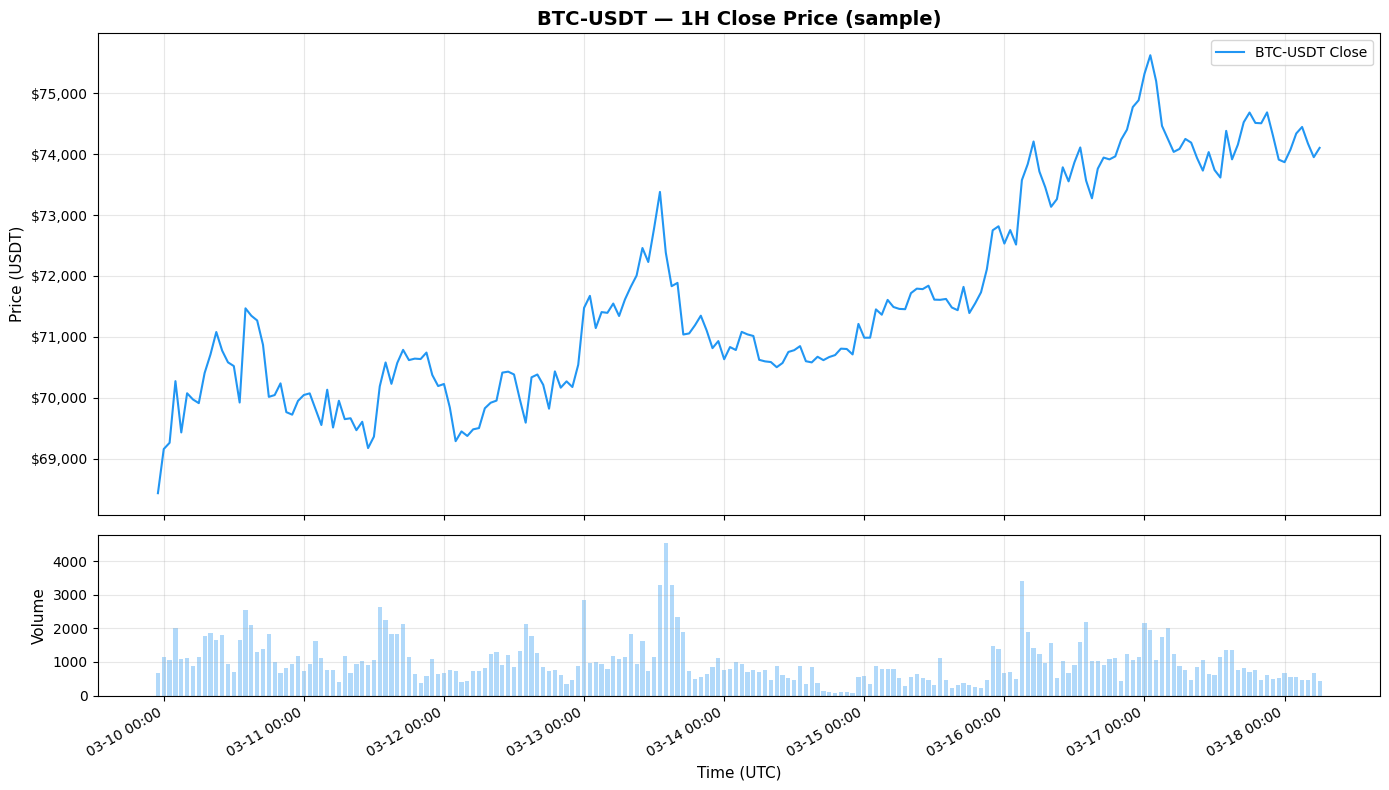

Chart saved to data/btc_sample_chart.png


In [9]:
plot_df = con.execute("""
    SELECT ts, close, volume
    FROM ohlcv
    WHERE symbol = 'BTC-USDT' AND interval = '1h'
    ORDER BY ts
""").fetchdf()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

# Price
ax1.plot(plot_df['ts'], plot_df['close'], color='#2196F3', linewidth=1.5, label='BTC-USDT Close')
ax1.set_title('BTC-USDT — 1H Close Price (sample)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USDT)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Volume bars
ax2.bar(plot_df['ts'], plot_df['volume'], color='#90CAF9', alpha=0.7, width=0.03, label='Volume')
ax2.set_ylabel('Volume', fontsize=11)
ax2.set_xlabel('Time (UTC)', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../data/btc_sample_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to data/btc_sample_chart.png')

## 7. Summary

In [10]:
print('=' * 50)
print('DuckDB Setup Complete')
print('=' * 50)
print(f'Database: {DB_PATH}')

all_tables = con.execute("SHOW TABLES").fetchdf()
for _, row in all_tables.iterrows():
    n = con.execute(f"SELECT COUNT(*) FROM {row['name']}").fetchone()[0]
    print(f'  {row["name"]:30s}  {n:>6} rows')

print('\nNext step: open 02_binance_loader.ipynb')

DuckDB Setup Complete
Database: ../data/research.duckdb
  backtest_metrics                     0 rows
  backtest_runs                        0 rows
  backtest_trades                      0 rows
  features                             0 rows
  mirofish_signals                     0 rows
  ml_predictions                       0 rows
  ohlcv                              200 rows
  signals                              0 rows
  trade_log                            0 rows
  unravel_signals                      0 rows

Next step: open 02_binance_loader.ipynb


In [12]:
df.to_csv('../data/btc_ohlcv.csv', index=False)
print(f'Saved {len(df)} rows to data/btc_ohlcv.csv')
df

Saved 200 rows to data/btc_ohlcv.csv


,ts,symbol,interval,open,high,low,close,volume,source
0,2026-03-09 23:00:00+00:00,BTC-USDT,1h,68635.88,68694.73,68384.69,68432.16,665.45565,binance
1,2026-03-10 00:00:00+00:00,BTC-USDT,1h,68432.16,69290.42,68391.41,69157.37,1134.03591,binance
2,2026-03-10 01:00:00+00:00,BTC-USDT,1h,69157.36,69389.06,68786.04,69260.01,1073.30020,binance
3,2026-03-10 02:00:00+00:00,BTC-USDT,1h,69260.00,70578.29,69103.12,70272.01,2010.96480,binance
4,2026-03-10 03:00:00+00:00,BTC-USDT,1h,70272.00,70370.86,69390.00,69429.85,1096.27179,binance
...,...,...,...,...,...,...,...,...,...
195,2026-03-18 02:00:00+00:00,BTC-USDT,1h,74072.30,74476.00,74051.78,74338.93,549.53806,binance
196,2026-03-18 03:00:00+00:00,BTC-USDT,1h,74338.93,74672.34,74250.27,74446.14,459.80928,binance
197,2026-03-18 04:00:00+00:00,BTC-USDT,1h,74446.14,74486.30,74137.02,74175.49,472.35206,binance
198,2026-03-18 05:00:00+00:00,BTC-USDT,1h,74175.48,74312.11,73830.76,73950.00,662.80056,binance


## 8. Close Connection

In [11]:
con.close()
print('Connection closed.')

Connection closed.
